# Глава 2. NaiveModel — наивный прогноз


## 1. Теория

### 1.1 Идея наивного прогноза
- Наивный прогноз - это когда в качестве прогноза для будущей точки берем последнее известное значение.

### 1.2 NaiveModel как обёртка над SeasonalMovingAverageModel
- Класс `NaiveModel` — это обертка над `SeasonalMovingAverageModel` с зафиксированным параметром `window=1`, который нельзя изменить. Получается, что глубина исторических данных всегда будет в 1 точку, и это будет последнее известное значение (либо значение с заданным сдвигом — см. 1.3).


### 1.3 Параметр `lag` и `context_size`
- `lag` в `NaiveModel` - это переименованный `seasonality` родительского класса `SeasonalMovingAverageModel`. Отдельного смысла `lag` не несёт - это `seasonality` под более понятным для наивной модели именем. А `seasonality` - это шаг сезонного цикла (гранулярность). Направляет фокус модели только на аналогичные точки в прошлом (например, строго в 12:00 каждого дня при `seasonality=24` для прогнозирования по аналогичным часам), полностью игнорируя соседние часы. Для наивного прогноза `seasonality` не календарная сезонность, а буквально "на сколько шагов назад смотреть", а `window=1` гарантирует, что это будет ровно одна точка, а не среднее нескольких.
- `make_future(future_steps=...)` — задает количество временных точек, которые мы хотим предсказать. Наш горизонт прогнозирования.
- `make_future(tail_steps=...)` — задает количество временных точек, которые мы хотим использовать для прогноза нашего горизонта. Это контекст модели, `model.context_size` (для `NaiveModel` он равен `lag`, так как `context_size = window * seasonality = 1 * lag`).
- `forecast(prediction_size=...)` —  говорит методу, что последние `prediction_size` меток это то, что нужно предсказать и вернуть. А всё, что стоит перед ними используется только как контекст для расчёта. Обычно `prediction_size == HORIZON`.


### 1.4 Золотое правило: `lag ≥ horizon`
Когда модель прогнозирует на много шагов вперед и каждый новый шаг опирается на только что сделанный прогноз (рекурсия), то в случае, когда первая точка предсказана неверно, ошибка будет расти лавинообразно и исказит точность прогнозов всех последующих временных точек. Поэтому модель всегда должна опираться только на исторические факты, и для этого должно соблюдаться простое правило: $$\large \text{Минимальный сдвиг (Lag)} \ge \text{Горизонт прогноза (Horizon)}$$. Таким образом, у модели всегда будет контекст исторических фактов, и прогнозы не будут строиться по прогнозам.


## 2. Данные
- `units.csv` — 10 юнитов в источнике; для практики берём только 2 из них — оба размера `10+` (typical + busier). Колонка `UnitSize` — размер, `PickReason` — busier/typical внутри размера.
- `facts-by-date.csv` — дневные факты по каждому юниту, 2022-01-01…2026-08-31.
- `forecasts-by-date.csv` — дневной прогноз текущей продовой модели; почти для всех юнитов доступен только за 2026-06-01…2026-08-31 (кроме `9bb64107` — там с 2025-12-29).
- `facts-by-hour.csv` / `forecasts-by-hour.csv` — то же самое по часам, но за более короткий период (факты — с 2025-12-01, прогноз — с 2026-06-01)

In [2]:
import pandas as pd

from etna.datasets import TSDataset
from etna.models import NaiveModel
from etna.metrics import SMAPE
from etna.analysis import plot_forecast
from torchgen.model import fk

DATA_DIR = "../../local/data"

## 3. Практика

### Задание 1. Загрузи данные по 2 юнитам размера `10+`

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier).
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Посмотри на `ts.describe()` — обрати внимание на `start_timestamp`/`num_missing` по каждому юниту (вспомни главу 1).
4. Построй `ts.plot()` — на глаз оцени, чем визуально отличаются busier и typical внутри `10+`.


In [3]:
units_df = (pd
.read_csv(filepath_or_buffer=f"{DATA_DIR}/units.csv")
.rename(columns={
    "MaskedUnitId": "segment",
    "UnitSize": "unit_size",
    "PickReason": "pick_reason"
})
[["segment", "unit_size", "pick_reason"]]

)

units_df = units_df[units_df["unit_size"] == "10+"]

orders_df = (
    pd.read_csv(f"{DATA_DIR}/facts-by-date.csv")
    .rename(columns={
        "CalendarDate": "timestamp",
        "MaskedUnitId": "segment",
        "Fact": "target",
    })
    [["timestamp", "segment", "target"]]
)

# Грязно выравниваем дату начала ряда, чтобы данные были по всем юнитам
orders_df = orders_df[orders_df['timestamp'] >= "2026-04-01"]
# Отбираем юниты
orders_df = orders_df.merge(units_df["segment"], how="inner", left_on="segment", right_on="segment", copy=True)

orders_ts = TSDataset(orders_df, freq="D")

In [4]:
orders_ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
70650540,2026-04-01,2026-08-31,153,0,2,0,0,0,D
a6dffdeb,2026-04-01,2026-08-31,153,0,2,0,0,0,D


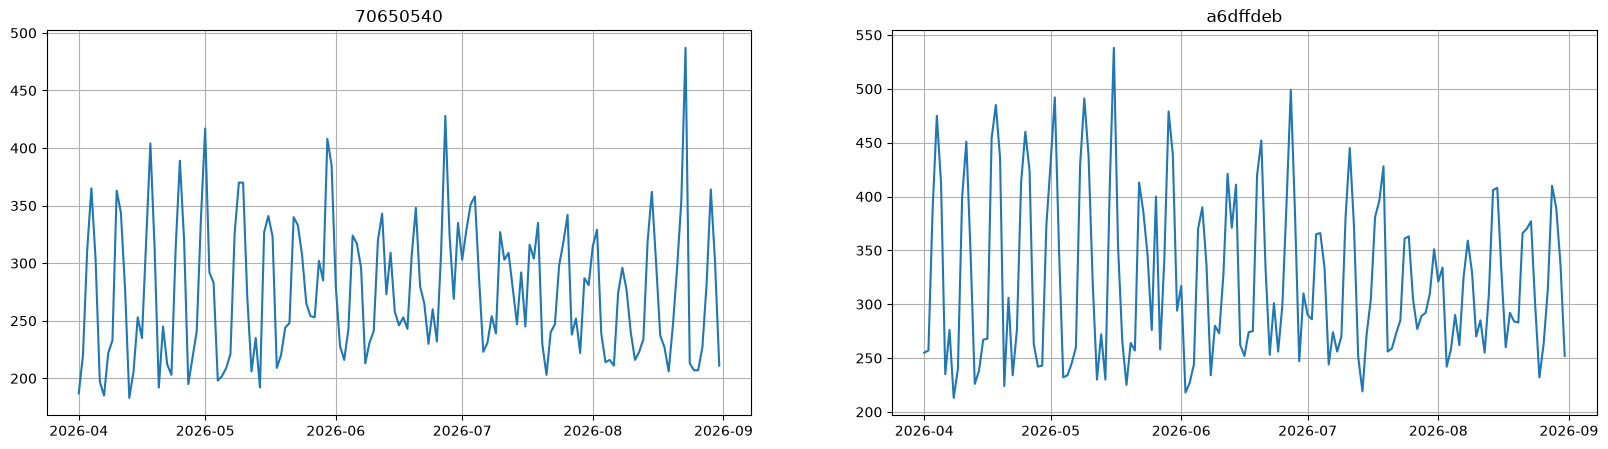

In [5]:
# 70650540: 10+ -> typical (p25)
# a6dffdeb: 10+ -> busier (p75)
orders_ts.plot()

### Задание 2. `lag` и золотое правило на одном юните

Возьми один юнит (например, самый «busier» из размера `10+`).

1. Выбери `HORIZON` (например, 14 дней) и раздели ряд на train/test так, чтобы последние `HORIZON` дней ушли в тест.
2. Обучи `NaiveModel(lag=1)`, сделай прогноз, посчитай `SMAPE`, визуализируй через `plot_forecast`.
3. Повтори для `lag=3`, `lag=HORIZON`, `lag=HORIZON + 5` (любое значение `> HORIZON`) — сравни, как меняется сам прогноз (не только метрика) и почему.
4. Сопоставь результат с золотым правилом из раздела 1.4.


In [6]:
smape = SMAPE()
HORIZONT = 14

In [7]:
train_ts, test_ts = orders_ts.train_test_split(test_size=HORIZONT)

In [29]:
def get_forecast(lag, horizont=HORIZONT, train=train_ts, test=test_ts, with_snapshot=False):
    model = NaiveModel(lag=lag)
    model.fit(train)

    future = train.make_future(
        future_steps=horizont,
        tail_steps=model.context_size
    )

    if with_snapshot:
        future_snapshot = future.to_pandas().copy()

    # mutates-in-place: future и forecast — один и тот же объект после этого вызова
    forecast = model.forecast(
        ts=future,
        prediction_size=horizont
    )

    metrics = smape(y_true=test, y_pred=forecast)
    plot_forecast(forecast_ts=forecast, test_ts=test, train_ts=train, n_train_samples=horizont)

    if with_snapshot:
        return future_snapshot, future, forecast, metrics
    return future, forecast, metrics

#### `lag=1`

{'70650540': 20.702356834958533, 'a6dffdeb': 20.939908756331786}

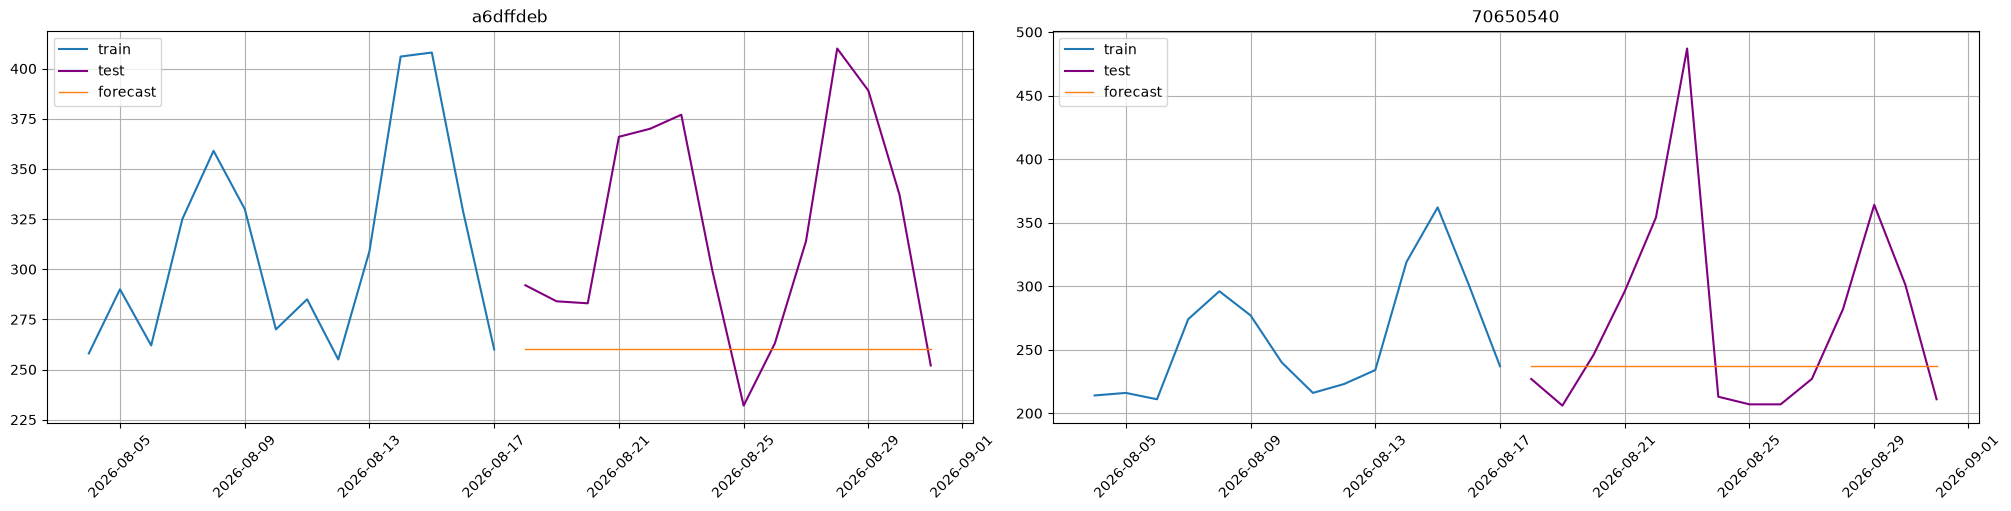

In [39]:
future_snapshot_1, future_1, forecast_1, metrics_1 = get_forecast(lag=1, with_snapshot=True)
metrics_1

In [31]:
future_snapshot_1

segment,70650540,a6dffdeb
feature,target,target
timestamp,,
2026-08-17,237.0,260.0
2026-08-18,NaN,NaN
2026-08-19,NaN,NaN
2026-08-20,NaN,NaN
2026-08-21,NaN,NaN
2026-08-22,NaN,NaN
2026-08-23,NaN,NaN
2026-08-24,NaN,NaN


In [32]:
future_1

segment,70650540,a6dffdeb
feature,target,target
timestamp,,
2026-08-18,237.0,260.0
2026-08-19,237.0,260.0
2026-08-20,237.0,260.0
2026-08-21,237.0,260.0
2026-08-22,237.0,260.0
2026-08-23,237.0,260.0
2026-08-24,237.0,260.0
2026-08-25,237.0,260.0


#### `lag=3`

{'70650540': 31.63381961660298, 'a6dffdeb': 22.532692204596714}

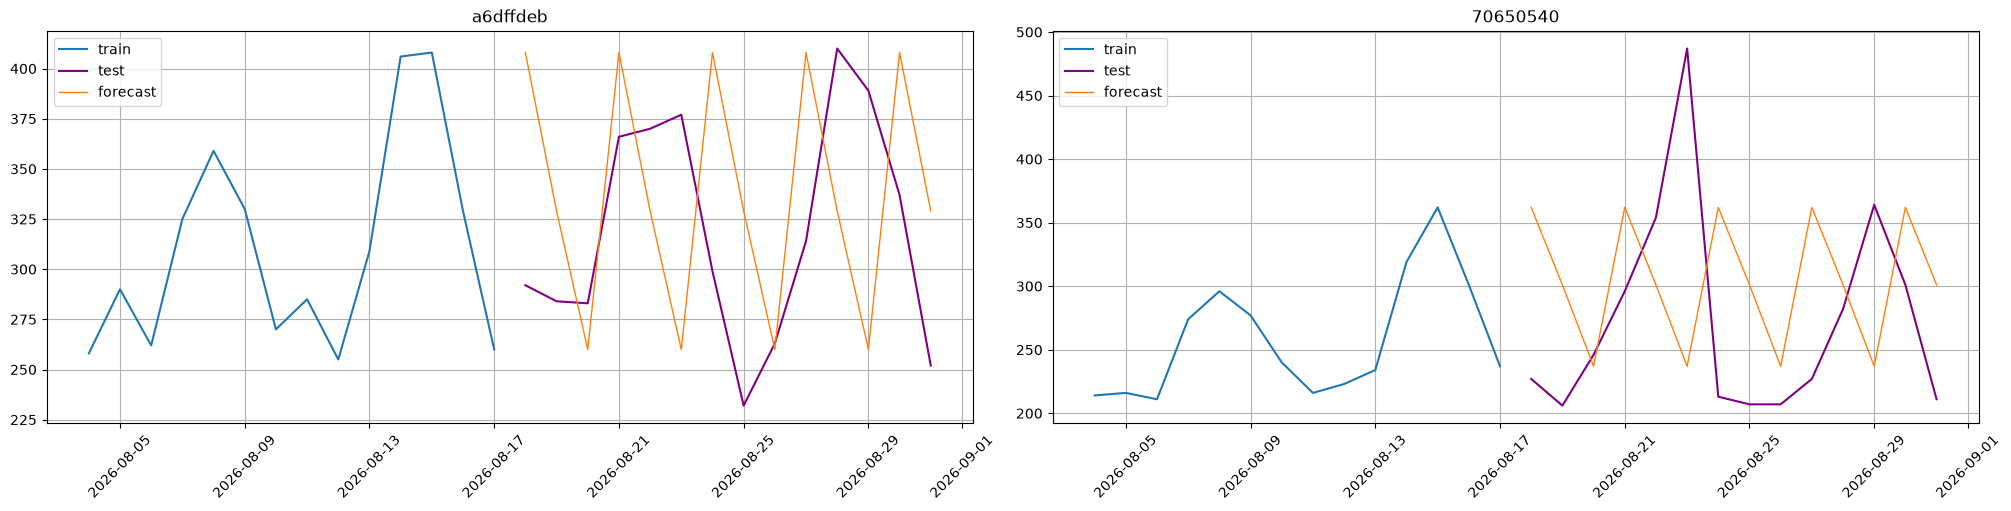

In [38]:
future_3, forecast_3, metrics_3 = get_forecast(lag=3)
metrics_3

#### `lag=h`

{'70650540': 11.258363830848074, 'a6dffdeb': 6.929056776235533}

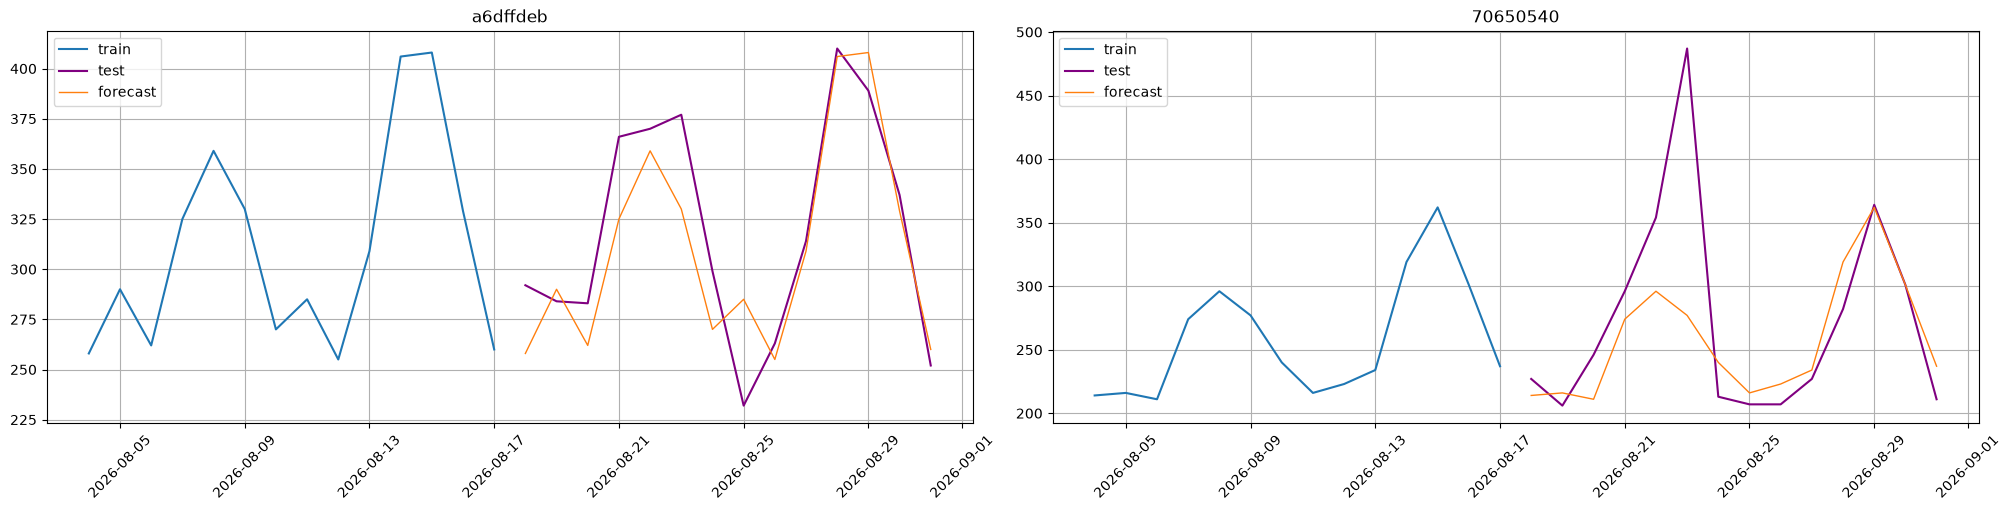

In [37]:
future_h, forecast_h, metrics_h = get_forecast(lag=HORIZONT)
metrics_h

#### `lag=h_5`

{'70650540': 24.628459680306168, 'a6dffdeb': 18.101589504770264}

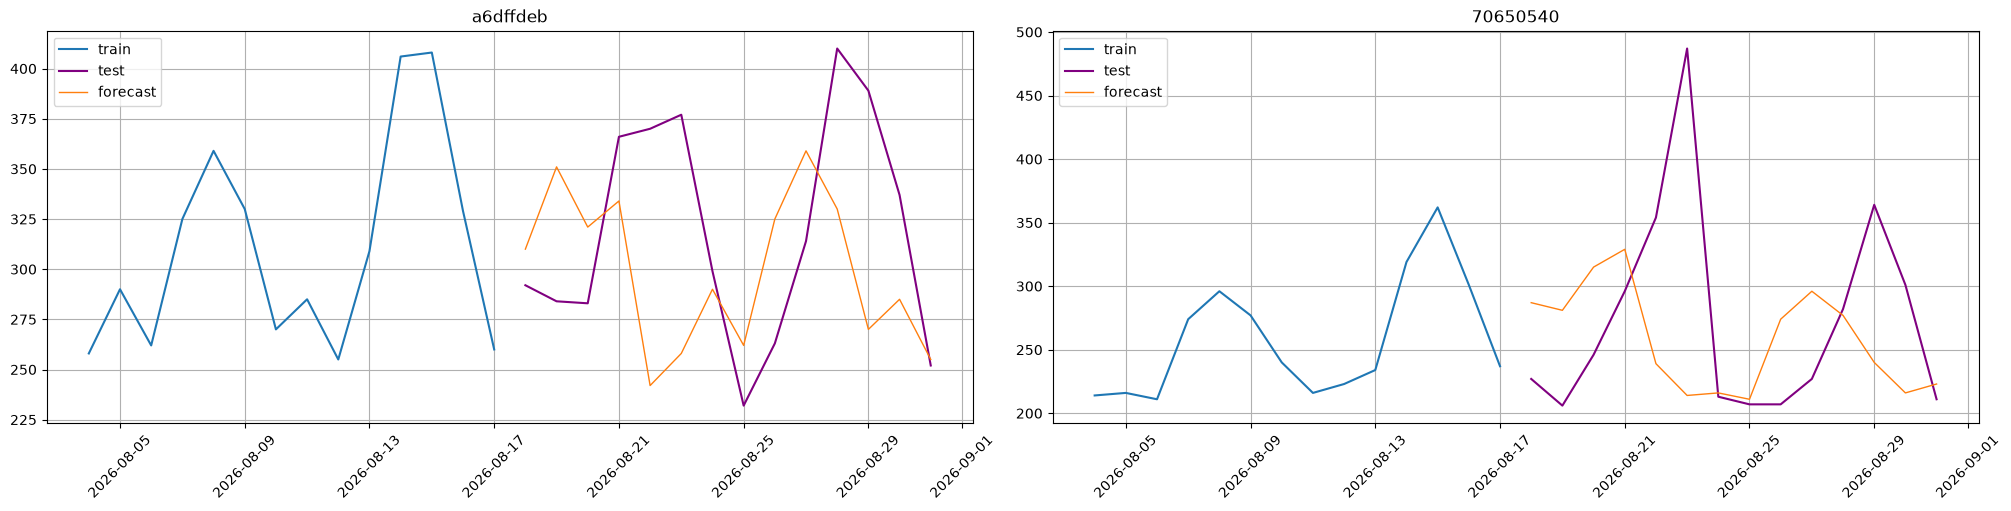

In [36]:
future_h_5, forecast_h_5, metrics_h_5 = get_forecast(lag=HORIZONT+5)
metrics_h_5

### Задание 3. Общая картина по обоим юнитам

1. Обучи лучший (по наблюдениям из Задания 2) вариант `NaiveModel` сразу на обоих сегментах.
2. Посчитай `SMAPE` по каждому юниту и `SMAPE(mode="macro")` как агрегат по обоим. Разберись, как считается сама формула SMAPE и что означает конкретное число (например, чем `SMAPE=11.26` отличается от `SMAPE=6.93` в терминах "на сколько процентов в среднем прогноз ошибается", и в каких границах лежит эта метрика).
3. Сравни ошибку `busier` и `typical` — на каком из двух наивный прогноз работает лучше и есть ли у тебя гипотеза, почему?


**Как считается `SMAPE`** (см. `etna.metrics.functional_metrics.smape`):

$$\large SMAPE = \frac{2 \cdot 100\%}{n} \sum_{i=1}^{n} \frac{|y\_true_i - y\_pred_i|}{|y\_true_i| + |y\_pred_i|}$$

- считается по каждой точке горизонта теста, затем усредняется по `n` точкам — отдельно для каждого сегмента (`mode="per-segment"`, значение по умолчанию).
- диапазон значений: `0%` (идеальный прогноз) … `200%` (максимальная ошибка).
- если `y_true[i] + y_pred[i] == 0` (и факт, и прогноз — ноль; у нас в данных такое реально бывает), знаменатель подстраховывается через `eps`, чтобы не делить на 0.
- `mode="macro"` не пересчитывает формулу заново — берёт уже посчитанные per-segment значения и усредняет их арифметически по сегментам.


In [43]:
# Переиспользуем forecast_h/metrics_h из Задания 2 (lag=HORIZONT — "лучший" вариант по золотому правилу,
# уже обучен и посчитан сразу на обоих сегментах, повторно fit/forecast не нужен)
print("SMAPE по каждому юниту (per-segment):")
print(metrics_h)

# mode="macro" — то же самое, но усреднённое в одно число по обоим сегментам
smape_macro = SMAPE(mode="macro")
metric_aggregated = smape_macro(y_true=test_ts, y_pred=forecast_h)
print(f"\nSMAPE (macro, среднее по 2 юнитам): {metric_aggregated:.2f}")

# Подписываем сегменты
segment_to_reason = units_df.set_index("segment")["pick_reason"].to_dict()
print("\nС разбивкой по PickReason:")
for segment, value in metrics_h.items():
    print(f"  {segment} ({segment_to_reason[segment]}): SMAPE = {value:.2f}")


SMAPE по каждому юниту (per-segment):
{'70650540': 11.258363830848074, 'a6dffdeb': 6.929056776235533}

SMAPE (macro, среднее по 2 юнитам): 9.09

С разбивкой по PickReason:
  70650540 (typical (p25)): SMAPE = 11.26
  a6dffdeb (busier (p75)): SMAPE = 6.93
